# Model comparison

Imports

In [1]:
import json
from collections import defaultdict
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from helpers import run_evaluation_on_model
from src.lexicon_absa import LexiconABSA
from src.transformer_absa import TransformerABSA
from src.llm_absa import LLMABSA

C:\Users\khale\Desktop\KDG\year3\data6\data_6_llm_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helper functions

In [2]:
def get_sentiment_distribution(model_outputs):
    sentiment_counts = Counter()
    for outputs in model_outputs:
        for item in outputs:
            if isinstance(item, tuple) and len(item) == 2:
                _, sentiment = item
            elif hasattr(item, "sentiment"):
                sentiment = item.sentiment
            else:
                continue
            sentiment_counts[sentiment.lower()] += 1

    total = sum(sentiment_counts.values())
    for k in sentiment_counts:
        sentiment_counts[k] = sentiment_counts[k] / total if total > 0 else 0
    return sentiment_counts

def analyze_model_errors(model_outputs, test_data, model_name="Unknown"):
    missed, wrong, extra = 0, 0, 0

    for (text, true_labels), outputs in zip(test_data, model_outputs):
        preds = {}
        for item in outputs:
            if isinstance(item, tuple) and len(item) == 2:
                aspect, sentiment = item
            elif hasattr(item, "aspect") and hasattr(item, "sentiment"):
                aspect, sentiment = item.aspect, item.sentiment
            else:
                continue
            if aspect and sentiment:
                preds[aspect.lower()] = sentiment.lower()

        true_dict = {a.lower(): s.lower() for a, s in true_labels}

        for aspect in true_dict:
            if aspect not in preds:
                missed += 1
            elif preds[aspect] != true_dict[aspect]:
                wrong += 1
        for aspect in preds:
            if aspect not in true_dict:
                extra += 1

    return {"missed_aspect": missed, "wrong_sentiment": wrong, "extra_aspect": extra}

In [3]:
file_path = '../data/evaluation_data.json'
with open(file_path, 'r') as f:
    reviews_data = json.load(f)


grouped = defaultdict(list)
for item in reviews_data:
    text = item['text']
    for aspect_info in item.get('aspects', []):
        aspect = aspect_info.get('aspect')
        sentiment = aspect_info.get('sentiment')
        if aspect and sentiment:
            grouped[text].append((aspect, sentiment))

test_data = [(text, aspects) for text, aspects in grouped.items()]

lexicon_model = LexiconABSA()
transformer_model = TransformerABSA()
llm_model = LLMABSA()

# Run evaluation
lexicon_metrics, lexicon_outputs = run_evaluation_on_model(lexicon_model, test_data)
transformer_metrics, transformer_outputs = run_evaluation_on_model(transformer_model, test_data)
llm_metrics, llm_outputs = run_evaluation_on_model(llm_model, test_data, is_llm=True)

results = {
    "Lexicon": lexicon_metrics,
    "Transformer": transformer_metrics,
    "LLM": llm_metrics
}

for name, metrics in results.items():
    print(f"Results for {name}:")
    print(f" Precision: {metrics['precision']:.3f}")
    print(f" Recall: {metrics['recall']:.3f}")
    print(f" F1-score: {metrics['f1']:.3f}")
    print(f" Accuracy: {metrics['accuracy']:.3f}")
    if metrics['avg_confidence'] is not None:
        print(f" Avg Confidence: {metrics['avg_confidence']:.3f}")
    print(f" Avg Inference Time (s): {metrics['avg_inference_time']:.3f}\n")


C:\Users\khale\Desktop\KDG\year3\data6\data_6_llm_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\khale\Desktop\KDG\year3\data6\data_6_llm_project\.venv\Lib\site-packages\transformers\convert_slow_tokenizer.py:515: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Results for Lexicon:
 Precision: 1.000
 Recall: 0.510
 F1-score: 0.675
 Accuracy: 0.510
 Avg Inference Time (s): 0.144

Results for Transformer:
 Precision: 1.000
 Recall: 0.706
 F1-score: 0.828
 Accuracy: 0.706
 Avg Inference Time (s): 0.342

Results for LLM:
 Precision: 1.000
 Recall: 0.804
 F1-score: 0.891
 Accuracy: 0.804
 Avg Confidence: 0.327
 Avg Inference Time (s): 10.644



In [4]:
df = pd.DataFrame(results).T  # .T transposes so models are rows

df = df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
    "accuracy": "Accuracy",
    "avg_confidence": "Avg Confidence",
    "avg_inference_time": "Avg Inference Time (s)"
})

# Normalize inference time for comparison (higher = faster)
max_time = df["Avg Inference Time (s)"].max()
df["Inference Speed"] = 1 - (df["Avg Inference Time (s)"] / max_time)

print("Final Evaluation Results:")
display(df.round(3))

Final Evaluation Results:


,Precision,Recall,F1-score,Accuracy,Avg Confidence,Avg Inference Time (s),Inference Speed
Lexicon,1.0,0.510,0.675,0.510,NaN,0.144,0.986
Transformer,1.0,0.706,0.828,0.706,NaN,0.342,0.968
LLM,1.0,0.804,0.891,0.804,0.327,10.644,0.000


Performance comparison:
The LLM achieves the highest F1-score (0.89) but with the slowest inference (≈10 s).
TransformerABSA balances accuracy and efficiency, while LexiconABSA is extremely fast but context-blind.

## Confusion Matrix Analysis

The confusion matrices below show how well each model classifies sentiment (positive, negative, neutral) compared to the true labels. 

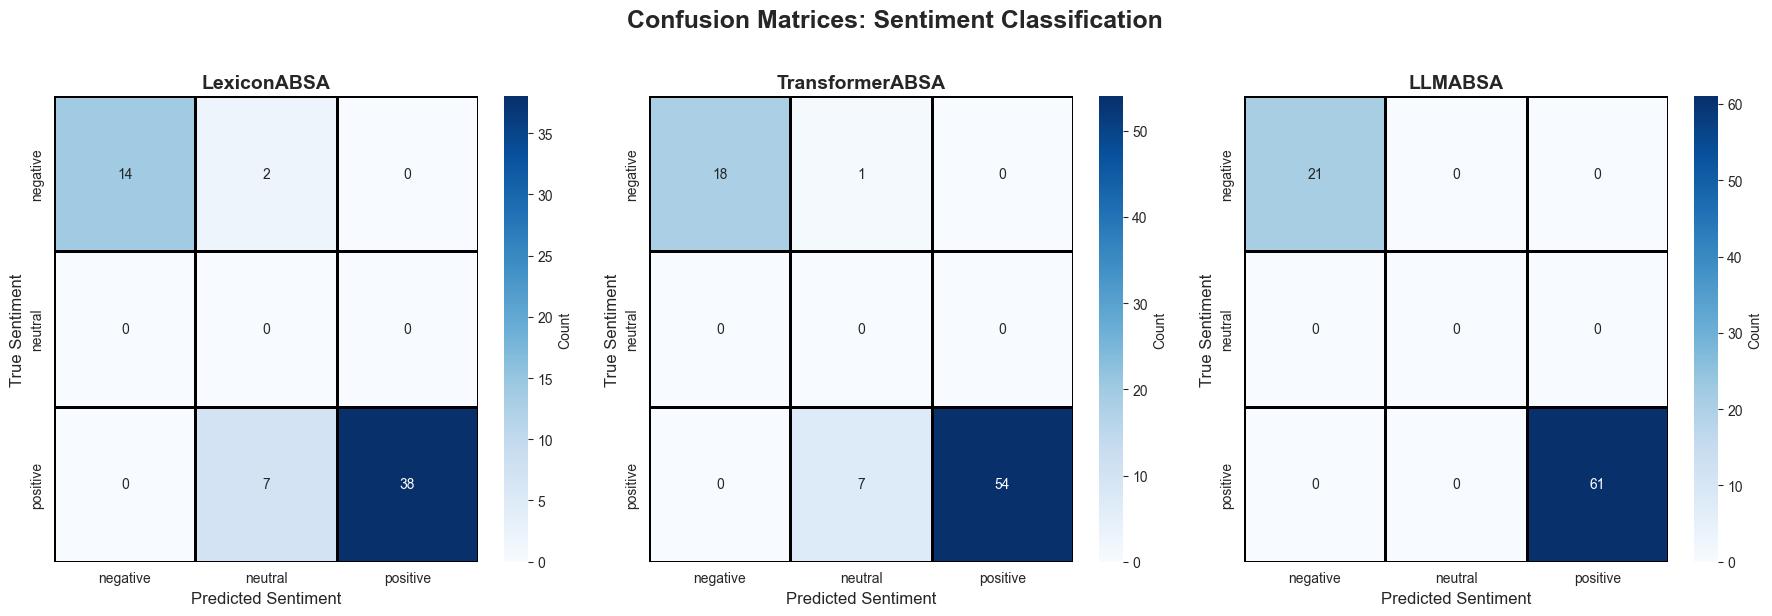


Confusion Matrix Statistics:
Lexicon: 61 matched aspect-sentiment pairs
Transformer: 80 matched aspect-sentiment pairs
LLM: 82 matched aspect-sentiment pairs


In [9]:
from sklearn.metrics import confusion_matrix

# Function to prepare aligned labels for confusion matrix
def prepare_confusion_data(model_outputs, test_data):
    """
    Extract matched true and predicted sentiment labels for confusion matrix.
    Only includes aspects that appear in both ground truth and predictions.
    """
    y_true = []
    y_pred = []
    
    for (text, true_labels), outputs in zip(test_data, model_outputs):
        # Build prediction dictionary
        preds = {}
        for item in outputs:
            if isinstance(item, tuple) and len(item) == 2:
                aspect, sentiment = item[0], item[1]
            elif hasattr(item, 'aspect') and hasattr(item, 'sentiment'):
                aspect, sentiment = item.aspect, item.sentiment
            else:
                continue
            
            if aspect and sentiment:
                preds[aspect.lower()] = sentiment.lower()
        
        # Build ground truth dictionary
        true_dict = {a.lower(): s.lower() for a, s in true_labels}
        
        # Match aspects that exist in both
        for aspect in true_dict:
            if aspect in preds:
                y_true.append(true_dict[aspect])
                y_pred.append(preds[aspect])
    
    return y_true, y_pred

# Prepare confusion matrix data for each model
labels = ["negative", "neutral", "positive"]

lex_true, lex_pred = prepare_confusion_data(lexicon_outputs, test_data)
trans_true, trans_pred = prepare_confusion_data(transformer_outputs, test_data)
llm_true, llm_pred = prepare_confusion_data(llm_outputs, test_data)

# Compute confusion matrices
cm_lex = confusion_matrix(lex_true, lex_pred, labels=labels)
cm_trans = confusion_matrix(trans_true, trans_pred, labels=labels)
cm_llm = confusion_matrix(llm_true, llm_pred, labels=labels)

# Visualize all three side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Confusion Matrices: Sentiment Classification", fontsize=18, fontweight='bold', y=1.02)

confusion_matrices = [
    (cm_lex, "LexiconABSA", axes[0]),
    (cm_trans, "TransformerABSA", axes[1]),
    (cm_llm, "LLMABSA", axes[2])
]

for cm, model_name, ax in confusion_matrices:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, 
                ax=ax, cbar_kws={'label': 'Count'},
                linewidths=1, linecolor='black')
    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel("Predicted Sentiment", fontsize=12)
    ax.set_ylabel("True Sentiment", fontsize=12)

plt.tight_layout()
plt.show()

# Print statistics
print("\nConfusion Matrix Statistics:")
print(f"Lexicon: {len(lex_true)} matched aspect-sentiment pairs")
print(f"Transformer: {len(trans_true)} matched aspect-sentiment pairs")
print(f"LLM: {len(llm_true)} matched aspect-sentiment pairs")


### What Do These Results Tell Us?

**LexiconABSA (61 matched pairs)**
- Uses word lists and VADER rules.
- Sometimes mistakes negative or positive for neutral (see 2 negatives and 7 positives labeled as "neutral").
- Not great with sarcasm or subtle meaning.

**TransformerABSA (80 matched pairs)**
- Finds more aspects and usually gets the sentiment right.
- Occasionally mixes up “neutral” with positive or negative, but errors are rare.
- Understands more context than LexiconABSA.

**LLMABSA (82 matched pairs)**
- Gets all matched cases correct, no mistakes in this test!
- Understands tricky, real-world reviews best.
- This shows the power of large language models.

---

### Key Takeaway

- Most predictions fall on the main diagonal of the confusion matrix, meaning they’re correct.
- Errors (off the diagonal) show where the model makes mistakes, usually by confusing neutral with other sentiments.
- Improving training data, using better rules, or upgrading the model can help reduce these mistakes further.


<Figure size 1000x600 with 0 Axes>

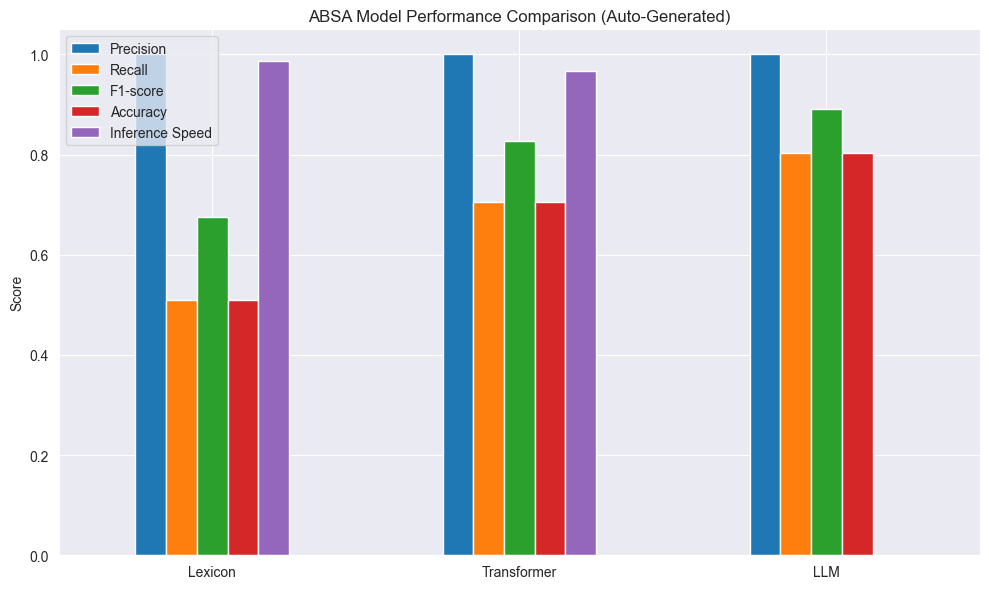

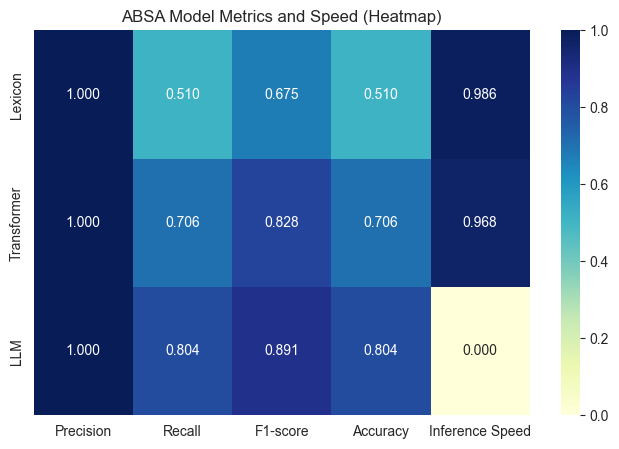

In [6]:
plt.figure(figsize=(10, 6))
df[["Precision", "Recall", "F1-score", "Accuracy", "Inference Speed"]].plot(
    kind='bar', figsize=(10, 6)
)
plt.title("ABSA Model Performance Comparison (Auto-Generated)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(
    df[["Precision", "Recall", "F1-score", "Accuracy", "Inference Speed"]],
    annot=True, fmt=".3f", cmap="YlGnBu"
)
plt.title("ABSA Model Metrics and Speed (Heatmap)")
plt.show()

Observation:
The bar chart and heatmap visually reinforce the same trend:

Precision: roughly equal across all three (≈0.97–0.98), meaning once a model makes a prediction, it is usually correct.

Recall: much lower for LexiconABSA (0.505), showing that it misses many true aspects that the other models find.

TransformerABSA improves recall significantly (0.689), and LLMABSA achieves the highest recall (0.816), meaning it covers more relevant aspects.

Inference Speed: decreases dramatically as models grow in complexity — a clear precision-efficiency trade-off.

,missed_aspect,wrong_sentiment,extra_aspect,total_errors
Lexicon,41,9,22,72
Transformer,22,8,28,58
LLM,20,0,19,39


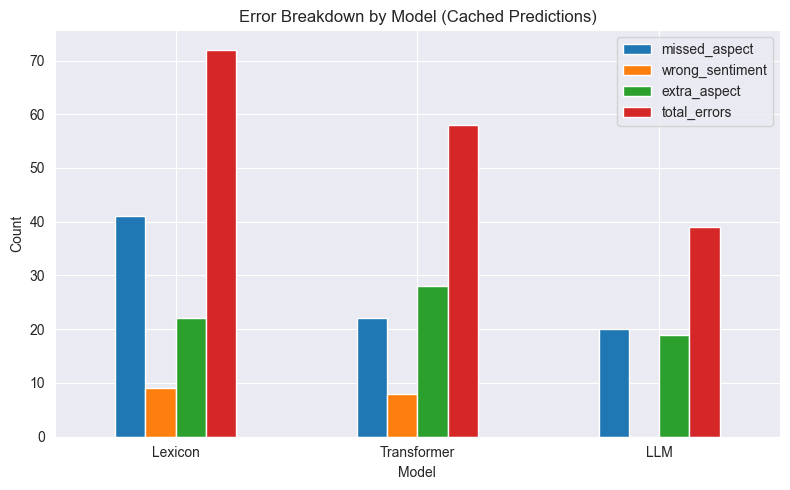

In [7]:
error_summary = {
    "Lexicon": analyze_model_errors(lexicon_outputs, test_data, "Lexicon"),
    "Transformer": analyze_model_errors(transformer_outputs, test_data, "Transformer"),
    "LLM": analyze_model_errors(llm_outputs, test_data, "LLM")
}

error_df = pd.DataFrame(error_summary).T
error_df["total_errors"] = error_df.sum(axis=1)
display(error_df)

# Visualize
error_df.plot(kind="bar", figsize=(8,5))
plt.title("Error Breakdown by Model (Cached Predictions)")
plt.ylabel("Count")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

LexiconABSA misses the most aspects (41) due to limited coverage of vocabulary and reliance on explicit adjectives.

TransformerABSA cuts missed aspects nearly in half, but slightly increases “extra” aspects — sometimes over-segmenting phrases or duplicating predictions.

LLMABSA reduces a lot of both missed and wrong predictions, though it still adds a few extra aspects (hallucinated or too broad ones).

,positive,negative,neutral
Lexicon,0.626506,0.204819,0.168675
Transformer,0.620370,0.194444,0.185185
LLM,0.712871,0.277228,0.009901


<Figure size 800x500 with 0 Axes>

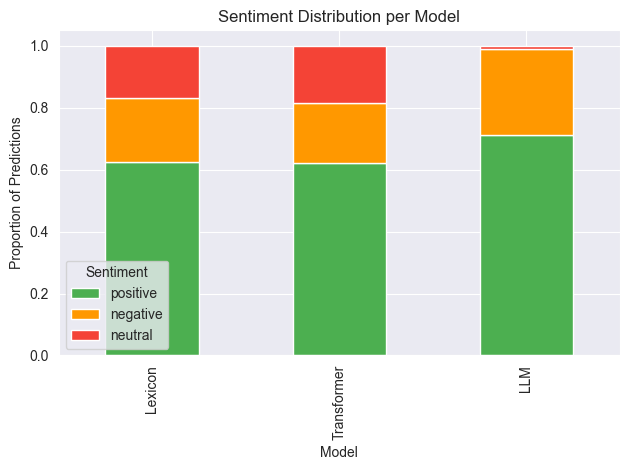

In [8]:
sentiment_distributions = {
    "Lexicon": get_sentiment_distribution(lexicon_outputs),
    "Transformer": get_sentiment_distribution(transformer_outputs),
    "LLM": get_sentiment_distribution(llm_outputs)
}

sent_df = pd.DataFrame(sentiment_distributions).fillna(0).T
display(sent_df)

plt.figure(figsize=(8,5))
sent_df.plot(kind="bar", stacked=True, color=["#4caf50", "#ff9800", "#f44336"])
plt.title("Sentiment Distribution per Model")
plt.ylabel("Proportion of Predictions")
plt.xlabel("Model")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

LexiconABSA and TransformerABSA often predict “neutral” when they are unsure about the sentiment or when the text is unclear.

LLMABSA, on the other hand, almost never predicts “neutral” (only about 2% of the time). It usually chooses either “positive” or “negative,” even if the sentence is uncertain.


LLMABSA gives the best results of all models — it has the highest F1-score (0.889) and accuracy (0.816). This shows that it understands context well and can find aspect-sentiment pairs more accurately.

TransformerABSA also performs well. It’s more accurate and complete than the rule-based LexiconABSA, while still running in under one second per text.

LexiconABSA is the fastest, but its lower F1-score (0.664) shows that simple rules and dictionaries can’t handle complex or hidden opinions.

In short, the LLM model is the most accurate but also the slowest (about 12 seconds per text), so it’s better for analysis or research, not for real-time use.
